<a href="https://colab.research.google.com/github/ThLanBot42/DHU_AI_THL_CV_COMP_COMPETITION/blob/main/Firegazing_V1.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install -q ultralytics
import torch, os, shutil, random, cv2, matplotlib.pyplot as plt
from google.colab import drive

# 强制挂载（防断连）
drive.mount('/content/drive', force_remount=True)

# 常量（每个 Cell 都带，防重启丢失）
DRIVE_ROOT = '/content/drive/MyDrive/AI_competition'
LOCAL_ROOT = '/content/datasets/wheat'

print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"显存: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Drive 挂载状态: {os.path.exists(DRIVE_ROOT)}")

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-80GB
显存: 85.1 GB
Drive 挂载状态: True


In [6]:
import os, shutil, random

DRIVE_ROOT = '/content/drive/MyDrive/AI_competition'
LOCAL_ROOT = '/content/datasets/wheat'

# ================== 1. 恢复被拆散的 val 到 train ==================
train_img = f'{DRIVE_ROOT}/images/train'
val_img   = f'{DRIVE_ROOT}/images/val'
os.makedirs(train_img, exist_ok=True)
os.makedirs(val_img, exist_ok=True)

moved = 0
for f in os.listdir(val_img):
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
        src = os.path.join(val_img, f)
        dst = os.path.join(train_img, f)
        if os.path.exists(src):
            shutil.move(src, dst)
            moved += 1
print(f"✅ 已从 val 恢复 {moved} 张图片到 images/train")

# ================== 2. 建立本地高速目录 ==================
for s in ['train', 'val', 'test']:
    os.makedirs(f'{LOCAL_ROOT}/images/{s}', exist_ok=True)
    os.makedirs(f'{LOCAL_ROOT}/labels/{s}', exist_ok=True)

# ================== 3. 符号链接图片到本地（不复制，秒完成）==================
for split in ['train', 'test']:
    d_src = f'{DRIVE_ROOT}/images/{split}'
    d_dst = f'{LOCAL_ROOT}/images/{split}'
    if os.path.exists(d_src):
        for f in os.listdir(d_src):
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                s = os.path.join(d_src, f)
                d = os.path.join(d_dst, f)
                if not os.path.exists(d):
                    os.symlink(s, d)

n_train = len([f for f in os.listdir(f'{LOCAL_ROOT}/images/train')
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))])
n_test = len([f for f in os.listdir(f'{LOCAL_ROOT}/images/test')
              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))])
print(f"✅ 本地图片链接 | train: {n_train} | test: {n_test}")

# ================== 4. 搬运伪标签 + 强制修复类别 ==================
DRIVE_PSEUDO = f'{DRIVE_ROOT}/pseudo_labels_train/labels'
LOCAL_LBL = f'{LOCAL_ROOT}/labels/train'
os.makedirs(LOCAL_LBL, exist_ok=True)

if not os.path.exists(DRIVE_PSEUDO):
    raise FileNotFoundError(f"❌ 找不到伪标签目录: {DRIVE_PSEUDO}\n   请确认 Drive 里已重命名为 pseudo_labels_train")

pseudo_files = [f for f in os.listdir(DRIVE_PSEUDO) if f.endswith('.txt')]
for f in pseudo_files:
    shutil.copy(os.path.join(DRIVE_PSEUDO, f), os.path.join(LOCAL_LBL, f))
print(f"✅ 伪标签已搬运: {len(pseudo_files)} 个")

# 修复：强制类别索引为 0，清洗非法坐标
fixed = 0
for fname in os.listdir(LOCAL_LBL):
    if not fname.endswith('.txt'):
        continue
    fpath = os.path.join(LOCAL_LBL, fname)
    with open(fpath, 'r') as fp:
        lines = fp.readlines()
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            parts[0] = '0'
            try:
                x, y, bw, bh = map(float, parts[1:5])
                if 0 <= x <= 1 and 0 <= y <= 1 and 0 < bw <= 1 and 0 < bh <= 1:
                    new_lines.append(' '.join(parts) + '\n')
            except:
                continue
    with open(fpath, 'w') as fp:
        fp.writelines(new_lines)
    if new_lines:
        fixed += 1
print(f"✅ 已修复/清洗 {fixed} 个标签文件")

# ================== 5. 划分验证集（Copy 模式，不动 train 原文件）==================
random.seed(42)

lbl_names = set(os.path.splitext(f)[0] for f in os.listdir(LOCAL_LBL) if f.endswith('.txt'))
img_files = [f for f in os.listdir(f'{LOCAL_ROOT}/images/train')
             if os.path.splitext(f)[0] in lbl_names
             and f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]

random.shuffle(img_files)
val_num = max(1, int(len(img_files) * 0.1))
val_imgs = img_files[:val_num]

for img_name in val_imgs:
    # 复制图片到 val
    shutil.copy(os.path.join(f'{LOCAL_ROOT}/images/train', img_name),
                os.path.join(f'{LOCAL_ROOT}/images/val', img_name))
    # 复制对应标签到 val
    lbl_name = os.path.splitext(img_name)[0] + '.txt'
    src_lbl = os.path.join(LOCAL_LBL, lbl_name)
    dst_lbl = os.path.join(f'{LOCAL_ROOT}/labels/val', lbl_name)
    if os.path.exists(src_lbl):
        shutil.copy(src_lbl, dst_lbl)

print(f"✅ 验证集: {val_num} 张 | 训练集剩余: {len(img_files) - val_num} 张")

# ================== 6. 生成 data.yaml ==================
yaml_content = f"""path: {LOCAL_ROOT}
train: images/train
val: images/val
test: images/test

nc: 1
names: ['wheat']"""

with open(f'{LOCAL_ROOT}/data.yaml', 'w') as f:
    f.write(yaml_content.strip())
print("✅ data.yaml 已创建")

# ================== 7. 数据完整性检查（必跑！）==================
for split in ['train', 'val']:
    idir = f'{LOCAL_ROOT}/images/{split}'
    ldir = f'{LOCAL_ROOT}/labels/{split}'
    imgs = set(os.path.splitext(f)[0] for f in os.listdir(idir)
               if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')))
    lbls = set(os.path.splitext(f)[0] for f in os.listdir(ldir) if f.endswith('.txt'))
    matched = imgs & lbls
    print(f"[{split}] 图片: {len(imgs)} | 标签: {len(lbls)} | 匹配: {len(matched)}")
    if imgs - lbls:
        print(f"  ⚠️ {len(imgs - lbls)} 张图片无标签（模型未检测到小麦，属正常）")
    if lbls - imgs:
        print(f"  ❌ {len(lbls - imgs)} 个标签无对应图片（异常！）")

assert any(f.endswith('.txt') for f in os.listdir(f'{LOCAL_ROOT}/labels/train')), "❌ train 无标签，检查伪标签路径！"
print("\n🎯 数据准备完毕，进入 Cell 3 可视化检查伪标签质量")

✅ 已从 val 恢复 0 张图片到 images/train
✅ 本地图片链接 | train: 4116 | test: 1025
✅ 伪标签已搬运: 1208 个
✅ 已修复/清洗 1208 个标签文件
✅ 验证集: 120 张 | 训练集剩余: 1088 张
✅ data.yaml 已创建
[train] 图片: 4116 | 标签: 1208 | 匹配: 1208
  ⚠️ 2908 张图片无标签（模型未检测到小麦，属正常）
[val] 图片: 120 | 标签: 120 | 匹配: 120

🎯 数据准备完毕，进入 Cell 3 可视化检查伪标签质量


/tmp/ipykernel_780/2128974470.py:49: UserWarning: Glyph 20266 (\N{CJK UNIFIED IDEOGRAPH-4F2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/2128974470.py:49: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/2128974470.py:49: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/2128974470.py:49: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/2128974470.py:49: UserWarning: Glyph 35270 (\N{CJK UNIFIED IDEOGRAPH-89C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/2128974470.py:49: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/2128974470.py:49: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missi

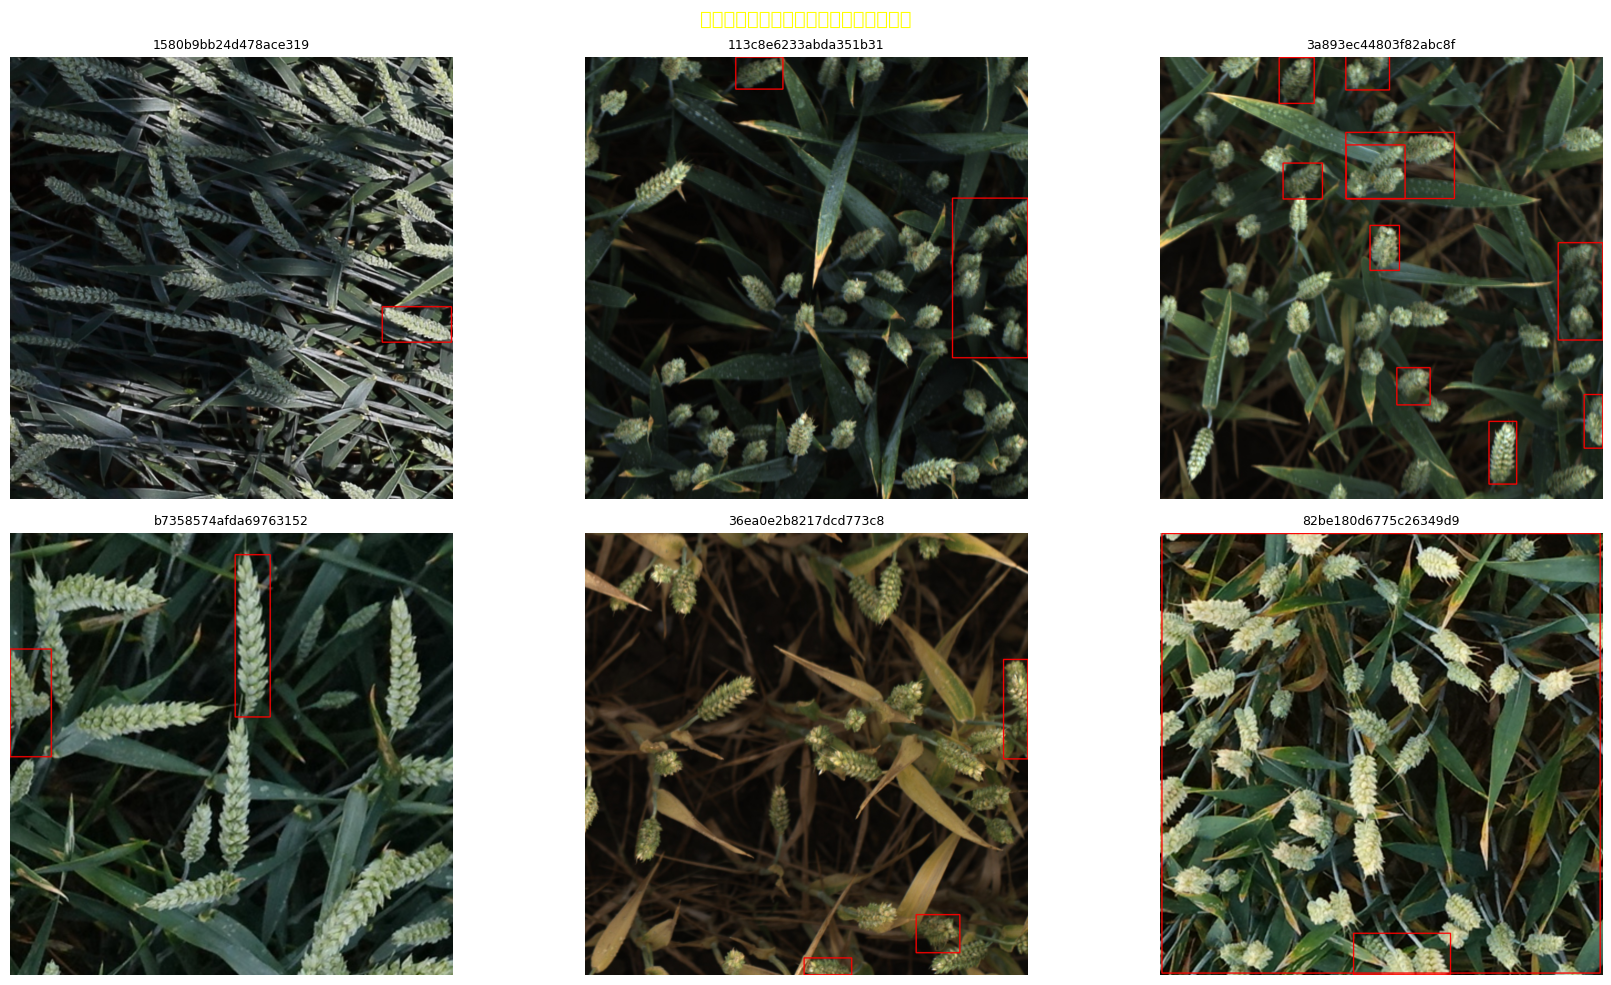

In [7]:
import os, random, cv2, matplotlib.pyplot as plt

LOCAL_ROOT = '/content/datasets/wheat'

def visualize(num=6):
    img_dir = f'{LOCAL_ROOT}/images/train'
    lbl_dir = f'{LOCAL_ROOT}/labels/train'
    files = [f for f in os.listdir(lbl_dir) if f.endswith('.txt')]
    random.shuffle(files)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, lf in enumerate(files[:num]):
        base_name = os.path.splitext(lf)[0]
        img_name = None
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.PNG', '.JPEG']:
            if os.path.exists(os.path.join(img_dir, base_name + ext)):
                img_name = base_name + ext
                break

        if not img_name:
            axes[i].text(0.5, 0.5, 'No image', ha='center')
            axes[i].axis('off')
            continue

        img = cv2.imread(os.path.join(img_dir, img_name))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        with open(os.path.join(lbl_dir, lf), 'r') as f:
            for line in f:
                p = line.strip().split()
                if len(p) == 5:
                    _, x, y, bw, bh = map(float, p)
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        axes[i].imshow(img)
        axes[i].set_title(img_name[:20], fontsize=9)
        axes[i].axis('off')

    plt.suptitle('伪标签可视化（蓝框必须大致套住麦穗）', fontsize=14, color='yellow')
    plt.tight_layout()
    plt.show()

visualize(6)

In [8]:
from ultralytics import YOLO

DRIVE_ROOT = '/content/drive/MyDrive/AI_competition'
LOCAL_ROOT = '/content/datasets/wheat'

# A100 用 yolov8m + batch=32 很轻松；如果显存够可以改 64
model = YOLO('yolov8m.pt')

model.train(
    data=f'{LOCAL_ROOT}/data.yaml',
    epochs=30,
    imgsz=640,
    batch=32,
    device=0,
    patience=10,            # 10 轮不提升就早停
    save=True,
    project=f'{DRIVE_ROOT}/training_runs',
    name='wheat_fast_val',
    exist_ok=True,
    optimizer='AdamW',
    lr0=0.001,
    augment=True,
    mosaic=1.0,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    verbose=True
)

print(f"\n✅ 训练完成！")
print(f"📁 最佳权重: {DRIVE_ROOT}/training_runs/wheat_fast_val/weights/best.pt")
print(f"📊 查看上面的 mAP50 值，若 > 0.1 则伪标签可用，明天换 yolov8x 冲榜")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/wheat/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wheat_fast_val, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_m

In [9]:
from ultralytics import YOLO
import os

DRIVE_ROOT = '/content/drive/MyDrive/AI_competition'
LOCAL_ROOT = '/content/datasets/wheat'

# 加载最佳模型
best_model = YOLO(f'{DRIVE_ROOT}/training_runs/wheat_fast_val/weights/best.pt')

# TTA 推理（augment=True 通常能提 1-3% mAP）
best_model.predict(
    source=f'{LOCAL_ROOT}/images/test',
    conf=0.25,              # 测试时降低阈值，提高召回
    save=True,
    save_txt=True,          # 生成的 txt 就是提交文件
    device=0,
    project=f'{DRIVE_ROOT}/test_results',
    name='submit_v1',
    exist_ok=True,
    augment=True            # 测试时增强（TTA）
)

print("✅ 推理完成！")
print(f"📁 提交标签目录: {DRIVE_ROOT}/test_results/submit_v1/labels")
print(f"📁 可视化结果目录: {DRIVE_ROOT}/test_results/submit_v1")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1025 /content/datasets/wheat/images/test/b643c321e44fb9b42aa48efee8f42bee2c6d2f852385d285ce5afa1c608181c1.png: 640x640 (no detections), 176.9ms
image 2/1025 /content/datasets/wheat/images/test/b6d83b4f23f980ab710b27c0efa12382289cd067e1132040b69be10c5e94d56c.png: 640x640 (no detections), 31.3ms
image 3/1025 /content/datasets/wheat/images/test/bc7bab61e2f9acce7fbf6fccad6c1f094561f30f877d58fc40c4ca6dd3fef718.png: 640x640 (no detections), 31.4ms
imag